<h2><b>DropOut Regularization Technique</b></h2>   

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import h5py
import time
import sklearn
import sklearn.datasets
import scipy.io

<h3><b>A Deep Feed Forward Neural Network with DropOut Regularization Method</b></h3>

In [32]:
def layer_sizes(X, Y, num_hidden_units):
    
    num_input_units = [X.shape[0]]
    num_output_units = [Y.shape[0]]
    num_hidden_units = list(num_hidden_units)
    
    num_layer_units = list(num_input_units + num_hidden_units + num_output_units)
    
    return num_layer_units


def initialize_parameters(num_layer_units):

    parameters = {}

    for l in range(1, len(num_layer_units)):
        
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * np.sqrt(2 / num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters


def sigmoid(Z):

    A = 1 / (1 + np.exp(-Z))
    cache = Z

    return A, cache


def relu(Z):

    A = np.maximum(0, Z)
    cache = Z
    
    return A, cache
  

def derivative_sigmoid(dA, cache):

    Z = cache
    A = 1 / (1 + np.exp(-Z))
    dZ = dA * A * (1 - A)
    assert (dZ.shape == Z.shape)
    
    return dZ


def derivative_relu(dA, cache):
    
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    
    assert (dZ.shape == Z.shape)
    
    return dZ


def helper_forward1(A_prev, W, b):

    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)

    return Z, cache


def helper_forward2(A_prev, W, b, activation):

    if activation == "relu":

        Z, linear_cache = helper_forward1(A_prev=A_prev, W=W, b=b)
        A, activation_cache = relu(Z=Z)
    elif activation == "sigmoid":

        Z, linear_cache = helper_forward1(A_prev=A_prev, W=W, b=b)
        A, activation_cache = sigmoid(Z=Z)
        
    cache = (linear_cache, activation_cache)

    return A, cache


def forward_propagation(X, parameters, hidden_activation, output_activation):

    caches = []
    A = X
    num_layers = len(parameters) // 2


    for l in range(1, num_layers):
        A_prev = A
        A, cache = helper_forward2(
            A_prev=A_prev, 
            W=parameters[f"W{l}"], 
            b=parameters[f"b{l}"], 
            activation=hidden_activation
        )
        caches.append(cache)

    A, cache = helper_forward2(
        A_prev=A, 
        W=parameters[f"W{num_layers}"], 
        b=parameters[f"b{num_layers}"], 
        activation=output_activation
    )
    caches.append(cache) 
    
    return A, caches


def helper_forward1_dropout(A_prev, W, b):

    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)

    return Z, cache


def helper_forward2_dropout(A_prev, W, b, activation, keep_prob):

    D = None

    if activation == "relu":

        Z, linear_cache = helper_forward1_dropout(A_prev=A_prev, W=W, b=b)
        A, activation_cache = relu(Z=Z)
        D = np.random.rand(A.shape[0], A.shape[1]) < keep_prob
        A = A * D / keep_prob
        
    elif activation == "sigmoid":

        Z, linear_cache = helper_forward1_dropout(A_prev=A_prev, W=W, b=b)
        A, activation_cache = sigmoid(Z=Z)
        
    if D is not None and D.any():
        cache = (linear_cache, activation_cache, D)
    else:
        cache = (linear_cache, activation_cache)
        

    return A, cache


def forward_propagation_dropout(X, parameters, hidden_activation, output_activation, keep_prob):

    caches = []
    A = X
    num_layers = len(parameters) // 2


    for l in range(1, num_layers):
        A_prev = A
        A, cache = helper_forward2_dropout(
            A_prev=A_prev, 
            W=parameters[f"W{l}"], 
            b=parameters[f"b{l}"], 
            activation=hidden_activation,
            keep_prob=keep_prob
        )
        caches.append(cache)

    A, cache = helper_forward2_dropout(
        A_prev=A, 
        W=parameters[f"W{num_layers}"], 
        b=parameters[f"b{num_layers}"], 
        activation=output_activation,
        keep_prob=keep_prob
    )
    caches.append(cache) 
    
    return A, caches


def compute_cost(A, Y, sigma):

    m = Y.shape[1]

    cost = - np.sum(np.multiply(Y, np.log(A+sigma)) + np.multiply(1 - Y, np.log(1 - A+sigma))) / m
    cost = np.squeeze(cost)

    return cost


def helper_backward1(dZ, cache):

    A_prev, W, b = cache
    m = A_prev.shape[1]
    
    dW = np.dot(dZ, A_prev.T) / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db


def helper_backward2(dA, cache, activation):

    linear_cache, activation_cache = cache

    if activation == "relu":

        dZ = derivative_relu(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)
        
    elif activation == "sigmoid":

        dZ = derivative_sigmoid(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)

    return dA_prev, dW, db


def backward_propagation(A, Y, caches, hidden_activation, output_activation, sigma):

    grads = {}
    L = len(caches)
    Y = Y.reshape(A.shape)

    dA = - (np.divide(Y, A + sigma) - np.divide(1 - Y, 1 - A + sigma))

    current_cache = caches[-1]
    dA_prev, dW, db = helper_backward2(dA=dA, cache=current_cache, activation=output_activation)
    grads[f"dW{L}"] = dW
    grads[f"db{L}"] = db
    grads[f"dA{L-1}"] = dA_prev

    
    for l in reversed(range(L - 1)):

        current_cache = caches[l]
        dA_prev, dW, db = helper_backward2(dA=grads[f"dA{l+1}"], cache=current_cache, activation=hidden_activation)
        grads[f"dW{l+1}"] = dW
        grads[f"db{l+1}"] = db
        grads[f"dA{l}"] = dA_prev
         

    return grads
    

def helper_backward1_dropout(dZ, cache):

    A_prev, W, b = cache
    m = A_prev.shape[1]
    
    dW = np.dot(dZ, A_prev.T) / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db


def helper_backward2_dropout(dA, cache, activation, keep_prob):
    
    if len(cache) == 3:
        linear_cache, activation_cache, D = cache
    else:
        linear_cache, activation_cache = cache
        

    if activation == "relu":

        dZ = derivative_relu(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1_dropout(dZ=dZ, cache=linear_cache)
        dA_prev = dA_prev * D
        dA_prev = dA_prev / keep_prob
        
    elif activation == "sigmoid":

        dZ = derivative_sigmoid(dA=dA, cache=activation_cache)
        dA_prev, dW, db = helper_backward1(dZ=dZ, cache=linear_cache)

    return dA_prev, dW, db


def backward_propagation_dropout(A, Y, caches, hidden_activation, output_activation, keep_prob, sigma):

    grads = {}
    L = len(caches)
    Y = Y.reshape(A.shape)

    dA = - (np.divide(Y, A + sigma) - np.divide(1 - Y, 1 - A + sigma))

    current_cache = caches[-1]
    dA_prev, dW, db = helper_backward2_dropout(dA=dA, cache=current_cache, activation=output_activation, keep_prob=keep_prob)
    grads[f"dW{L}"] = dW
    grads[f"db{L}"] = db
    grads[f"dA{L-1}"] = dA_prev

    
    for l in reversed(range(L - 1)):

        current_cache = caches[l]
        dA_prev, dW, db = helper_backward2_dropout(dA=grads[f"dA{l+1}"], cache=current_cache, activation=hidden_activation, keep_prob=keep_prob)
        grads[f"dW{l+1}"] = dW
        grads[f"db{l+1}"] = db
        grads[f"dA{l}"] = dA_prev
         

    return grads



def update_parameters(parameters, grads, learning_rate):

    parameters_ = copy.deepcopy(parameters)
    L = len(parameters_) // 2

    for l in range(L):
        
        parameters_[f"W{l+1}"] -= learning_rate * grads[f"dW{l+1}"]
        parameters_[f"b{l+1}"] -= learning_rate * grads[f"db{l+1}"]

    return parameters_

def predict(X, parameters, hidden_activation, output_activation):
    
    predicted = np.zeros((1, X.shape[1]))
    
    probabilities, caches = forward_propagation(
        X=X, 
        parameters=parameters,
        hidden_activation=hidden_activation,
        output_activation=output_activation
    )
    
    predicted[0, :] = (probabilities > 0.5)

    return predicted


def accuracy(predicted, Y):
    
    accuracy = np.sum((predicted == Y) / Y.shape[1])
    
    return accuracy



def train(X_train, Y_train, X_test, Y_test, parameters, hidden_activation, output_activation, num_epochs, learning_rate, print_cost, epsilon, sigma, keep_prob):

    train_cost = []
    test_cost = []
    durations = []
    
    for i in range(1, num_epochs+1):
        tic = time.time()

        if keep_prob == 1:
            
            A, caches = forward_propagation(
                X=X_train, 
                parameters=parameters,
                hidden_activation=hidden_activation,
                output_activation=output_activation
            )
            
            cost = compute_cost(A=A, Y=Y_train, sigma=sigma)
            train_cost.append(cost)
            
        else:
            
            A, caches = forward_propagation_dropout(
                X=X_train, 
                parameters=parameters,
                hidden_activation=hidden_activation,
                output_activation=output_activation,
                keep_prob=keep_prob
            )
            
            cost = compute_cost(A=A, Y=Y_train, sigma=sigma)
            train_cost.append(cost)
            

        A_test, _ = forward_propagation(
            X=X_test, 
            parameters=parameters,
            hidden_activation=hidden_activation,
            output_activation=output_activation
        )
        cost_t = compute_cost(A=A_test, Y=Y_test, sigma=sigma)
        test_cost.append(cost_t)

        if keep_prob == 1:
            
            grads = backward_propagation(
                A=A, 
                Y=Y_train, 
                caches=caches, 
                hidden_activation=hidden_activation,
                output_activation=output_activation,
                sigma=sigma
            )
            
        else:
            
            grads = backward_propagation_dropout(
                A=A, 
                Y=Y_train, 
                caches=caches, 
                hidden_activation=hidden_activation,
                output_activation=output_activation,
                keep_prob=keep_prob,
                sigma=sigma
            )
            

            
        parameters = update_parameters(
            parameters=parameters,
            grads=grads, 
            learning_rate=learning_rate
        )
        toc = time.time()
        durations.append(toc - tic)
        if print_cost and i % epsilon == 0:
            print(f"Epoch {i}; Cost: {cost}; Duration: {round(sum(durations[i-epsilon: i]), 3)} S")
        if i == num_epochs and i % epsilon != 0:
            print(f"Epoch {i}; Cost: {cost}; Duration: {round(toc - tic, 3)} S")
                
    
    train_predicted = predict(
        X=X_train, 
        parameters=parameters, 
        hidden_activation=hidden_activation,
        output_activation=output_activation
    )   
    train_accuracy = accuracy(predicted=train_predicted, Y=Y_train) 

    test_predicted = predict(
        X=X_test,
        parameters=parameters,
        hidden_activation=hidden_activation,
        output_activation=output_activation
    )   
    test_accuracy = accuracy(predicted=test_predicted, Y=Y_test)
    

    return (parameters, train_predicted, train_accuracy, train_cost, test_predicted, test_accuracy, test_cost)
    



def model(X_train, Y_train, X_test, Y_test, num_hidden_units, hidden_activation="relu", output_activation="sigmoid", keep_prob=1, num_epochs=10000, learning_rate=1e-4, print_cost=True, epsilon=1000, sigma=1e-12):

    
    num_layer_units = layer_sizes(X=X_train, Y=Y_train, num_hidden_units=num_hidden_units)
    parameters = initialize_parameters(num_layer_units=num_layer_units)
    

    if print_cost:
        print("___"*33)
        print(f"NN_Model with {len(num_hidden_units)+1} layers; Number of Epochs: {num_epochs}; Learning Rate: {learning_rate}; keep_prob: {keep_prob}")
        print("___"*33)
   
    
    train_params = train(X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test, 
                         parameters=parameters, hidden_activation=hidden_activation, 
                         output_activation=output_activation, num_epochs=num_epochs, 
                         learning_rate=learning_rate, print_cost=print_cost, epsilon=epsilon, sigma=sigma, keep_prob=keep_prob)
    

    parameters, train_predicted, train_accuracy, train_cost, test_predicted, test_accuracy, test_cost = train_params
 

    print("__"*20)
    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print("__"*20)
    
    plt.plot(train_cost, label="Train Cost")
    plt.plot(test_cost, label="Test Cost")
    plt.title("Epoch vs. Cost")
    plt.xlabel(f"Epoch Scaled by {epsilon}")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()
    
    return parameters
    

In [24]:
def load_2D_dataset():
    data = scipy.io.loadmat("/home/samani/Documents/projects/deep-learning/data/data.mat")
    train_X = data['X'].T
    train_Y = data['y'].T
    test_X = data['Xval'].T
    test_Y = data['yval'].T

    plt.scatter(train_X[0, :], train_X[1, :], c=train_Y, s=40, cmap=plt.cm.Spectral);
    
    return train_X, train_Y, test_X, test_Y

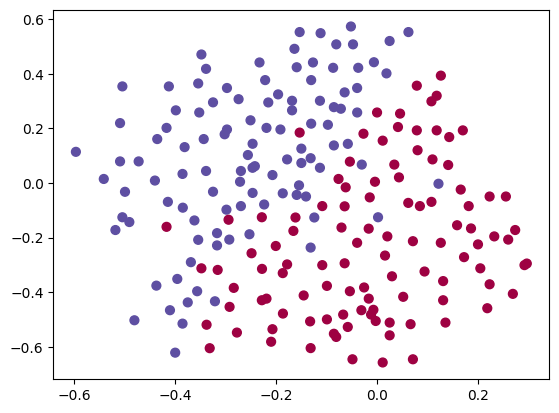

In [25]:
X_train, Y_train, X_test, Y_test = load_2D_dataset()

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 30000; Learning Rate: 0.3; keep_prob: 1
___________________________________________________________________________________________________
Epoch 2000; Cost: 0.19361673162056753; Duration: 0.652 S
Epoch 4000; Cost: 0.1598549259324602; Duration: 0.585 S
Epoch 6000; Cost: 0.15038982309593643; Duration: 0.581 S
Epoch 8000; Cost: 0.1362821117990325; Duration: 0.587 S
Epoch 10000; Cost: 0.14400179769983404; Duration: 0.583 S
Epoch 12000; Cost: 0.11753219663399798; Duration: 0.6 S
Epoch 14000; Cost: 0.11421328850816127; Duration: 0.594 S
Epoch 16000; Cost: 0.11187515609965414; Duration: 0.588 S
Epoch 18000; Cost: 0.090600799792858; Duration: 0.586 S
Epoch 20000; Cost: 0.0939620391650002; Duration: 0.591 S
Epoch 22000; Cost: 0.10728720888031448; Duration: 0.596 S
Epoch 24000; Cost: 0.08793453048442636; Duration: 0.841 S
Epoch 26000; Cost: 0.063581109249

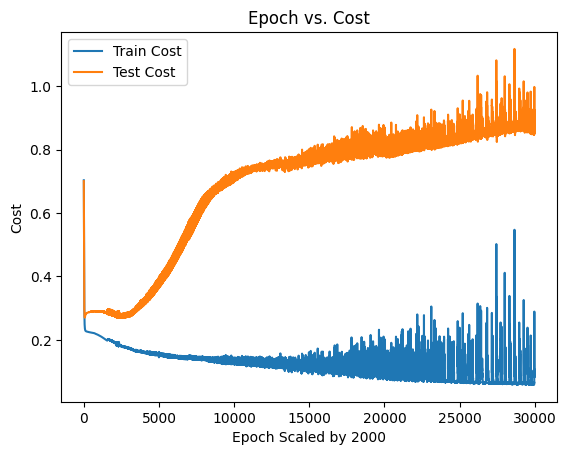

In [26]:
model1 = model(
    X_train, 
    Y_train, 
    X_test, 
    Y_test, 
    [20,10], 
    hidden_activation="relu",
    output_activation="sigmoid",
    keep_prob=1, 
    num_epochs=30000,
    learning_rate=0.3,
    print_cost=True, 
    epsilon=2000,
    sigma=1e-15
)

In [33]:
model2 = model(
    X_train, 
    Y_train, 
    X_test, 
    Y_test, 
    [20,10], 
    hidden_activation="relu",
    output_activation="sigmoid",
    keep_prob=0.85, 
    num_epochs=30000,
    learning_rate=0.3,
    print_cost=True, 
    epsilon=2000,
    sigma=1e-15
)

___________________________________________________________________________________________________
NN_Model with 3 layers; Number of Epochs: 30000; Learning Rate: 0.3; keep_prob: 0.85
___________________________________________________________________________________________________


ValueError: operands could not be broadcast together with shapes (20,211) (10,211) 